# Import Dataset.

In [3]:
import kagglehub

path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


# Importing the Required Librares.

In [17]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.naive_bayes import MultinomialNB

# Loading the Dataset and creating Dataframe.

In [5]:
data = pd.read_csv("/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")
df = pd.DataFrame(data)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# Preprocessing the reviews.

In [6]:
def clean_text(text):
  text = text.lower()
  text = re.sub(r'[^a-zA-Z]', ' ', text)
  return text

df["clean_review"] = df["review"].apply(clean_text)

In [7]:
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production br br the...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei s love in the time of money is...


# Implementing the TF-IDF vectorizer to convert text to numbers.

In [8]:
vector = TfidfVectorizer(stop_words='english', max_features=5000)
x = vector.fit_transform(df["clean_review"])
y = df["sentiment"]

# Implementing the Machine Learning model

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [10]:
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

# Calculating the model metrics.

In [16]:
y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8888
              precision    recall  f1-score   support

    negative       0.90      0.87      0.89      4961
    positive       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



# Implementing the Naive Bayes Algorithm

In [12]:
nb_model = MultinomialNB()
nb_model.fit(x_train, y_train)

MultinomialNB()

In [13]:
y_pred_nb = nb_model.predict(x_test)

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.8522
              precision    recall  f1-score   support

    negative       0.85      0.85      0.85      4961
    positive       0.85      0.86      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



[[4330  631]
 [ 481 4558]] 

[[4210  751]
 [ 727 4312]] 



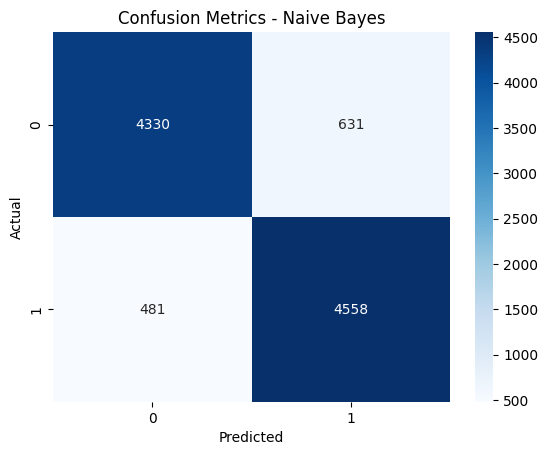

In [23]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
cm = confusion_matrix(y_test, y_pred)
print(cm, "\n")
print(cm_nb, "\n")

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Metrics - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()